In [1]:
import pandas as pd

# Carregar dados do novo path
df = pd.read_csv("../data/processed/carhacking_ciciov_benign_dos_aligned.csv")

# Remover linhas incompletas do Car-Hacking (ruido): source=CARDT com dlc<8.
if {'source', 'dlc'}.issubset(df.columns):
    incomplete_mask = (df['source'] == 'CARDT') & (df['dlc'] < 8)
    print(f"Removendo linhas incompletas CARDT (dlc<8): {int(incomplete_mask.sum())}")
    df = df.loc[~incomplete_mask].copy()

# Manter id + bytes para o treinamento
df = df[["id", "val0", "val1", "val2", "val3", "val4", "val5", "val6", "val7", "flag"]]
print(df.head())          # Ver as primeiras linhas
print(df['flag'].value_counts())  # Quantos exemplos tem de cada classe

Removendo linhas incompletas CARDT (dlc<8): 200665
    id  val0  val1  val2  val3  val4  val5  val6  val7    flag
0  790     5    33   104     9    33    33     0   111  BENIGN
1  399   254    91     0     0     0    60     0     0  BENIGN
2  608    25    33    34    48     8   142   109    58  BENIGN
3  672   100     0   154    29   151     2   189     0  BENIGN
4  809    64   187   127    20    17    32     0    20  BENIGN
flag
BENIGN    15261030
DoS         662183
RPM         654897
GEAR        597252
Fuzzy       491847
Name: count, dtype: int64


In [ ]:
print("hello")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Balancear BENIGN para manter o treino viavel
n_samples_benign = 1_000_000
benign_df = df[df['flag'] == 'BENIGN']
attack_df = df[df['flag'] != 'BENIGN']
benign_sampled = benign_df.sample(n=min(n_samples_benign, len(benign_df)), random_state=42)
df = pd.concat([benign_sampled, attack_df], axis=0)
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

df = df.dropna()
# Nao remover o id: ele e importante para separar classes ambiguas.

In [ ]:
print(df['flag'].value_counts())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Codificar rótulos em números
le = LabelEncoder()
df['flag'] = le.fit_transform(df['flag'])

X = df.drop(columns=['flag'])  # Features: id + bytes
y = df['flag']                 # Rótulos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=40)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
del df  # Liberar memória

In [ ]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # Definir o classificador base
# mlp = MLPClassifier(random_state=42, early_stopping=True)

# # Grade de hiperparâmetros
# param_grid = {
#     'hidden_layer_sizes': [(30,), (50,), (30, 30)],
#     'activation': ['relu', 'tanh'],
#     'alpha': [0.0001, 0.01, 0.1],
#     'learning_rate_init': [0.001, 0.01],
#     'solver': ['adam', 'sgd'],
#     'max_iter': [300]
# }

# # Validação cruzada estratificada
# cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# # Executa a busca
# grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, 
#                            scoring='accuracy', cv=cv, n_jobs=1, verbose=3)

# grid_search.fit(X, y)

# # Resultados
# print("Melhores parâmetros encontrados:")
# print(grid_search.best_params_)

# print(f"Melhor acurácia: {grid_search.best_score_:.4f}")


In [ ]:
# from sklearn.model_selection import cross_val_score, StratifiedKFold
# from sklearn.neural_network import MLPClassifier

# mlp_cv = MLPClassifier(
#     hidden_layer_sizes=(30, 30),
#     alpha=0.0001,
#     activation='relu',
#     max_iter=300,
#     solver='adam',
#     random_state=42,
#     early_stopping=True
# )

# cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# scores_10cv = cross_val_score(mlp_cv, X, y, cv=cv10, scoring='accuracy')

# print(f"Acurácia média (10x CV): {scores_10cv.mean():.4f} ± {scores_10cv.std():.4f}")

In [ ]:
# from sklearn.metrics import classification_report

# # Treinar o modelo com os dados de treino
# mlp_model = MLPClassifier(
#     hidden_layer_sizes=(30, 30),
#     alpha=0.0001,
#     activation='relu',
#     max_iter=300,
#     solver='adam',
#     random_state=42,
#     early_stopping=True
# )
# mlp_model.fit(X_train, y_train)

# # Prever nos dados de teste
# y_pred = mlp_model.predict(X_test)

# # Exibir relatório de classificação com 4 dígitos de precisão
# print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str), digits=5))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss, accuracy_score, classification_report

# Parâmetros
n_epochs = 25
classes = np.unique(y_train)

mlp_model = MLPClassifier(

    hidden_layer_sizes=(30, 30,30),

    alpha=0.0001,

    activation='relu',

    solver='adam',

    # --- COMBINAÇÃO PODEROSA ---

    learning_rate='adaptive',     # Ajusta a taxa de aprendizado automaticamente

    learning_rate_init=0.001,     # Pode manter o padrão ou reduzir se necessário

    #batch_size=128,             # Opcional: aumentar se ainda houver instabilidade

    max_iter=1,

    warm_start=True,

    random_state=90

)

# Listas para armazenar métricas por época
train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

# Treinamento manual por época
for epoch in range(n_epochs):
    mlp_model.fit(X_train, y_train)

    # Probabilidades para calcular log loss
    y_train_proba = mlp_model.predict_proba(X_train)
    y_test_proba = mlp_model.predict_proba(X_test)

    # Loss
    train_loss = log_loss(y_train, y_train_proba)
    test_loss = log_loss(y_test, y_test_proba)

    # Acurácia
    train_acc = accuracy_score(y_train, mlp_model.predict(X_train))
    test_acc = accuracy_score(y_test, mlp_model.predict(X_test))

    # Armazenar
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

# Após treino, imprimir relatório final
y_pred = mlp_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str), digits=5))


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Usar amostras reduzidas para manter o tempo de execução prático
xgb_train_sample_size = min(len(X_train), 400_000)
xgb_test_sample_size = min(len(X_test), 80_000)
X_train_xgb = X_train.sample(n=xgb_train_sample_size, random_state=42)
y_train_xgb = y_train.loc[X_train_xgb.index]
X_test_xgb = X_test.sample(n=xgb_test_sample_size, random_state=42)
y_test_xgb = y_test.loc[X_test_xgb.index]

print(f"Treinando XGBoost em {len(X_train_xgb)} amostras de treino e avaliando em {len(X_test_xgb)} amostras de teste.")

N_ROUNDS = 50

xgb_train_loss = []
xgb_test_loss  = []
xgb_train_acc  = []
xgb_test_acc   = []

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    n_estimators=1,
    learning_rate=0.1,
    random_state=42,
    verbosity=0,
    warm_start=True,
)

for i in range(1, N_ROUNDS + 1):
    xgb_model.n_estimators = i
    xgb_model.fit(
        X_train_xgb, y_train_xgb,
        eval_set=[(X_train_xgb, y_train_xgb), (X_test_xgb, y_test_xgb)],
        verbose=False,
    )
    # Loss da última árvore registrada pelo eval
    res = xgb_model.evals_result()
    xgb_train_loss.append(res['validation_0']['mlogloss'][-1])
    xgb_test_loss.append(res['validation_1']['mlogloss'][-1])
    # Acurácia
    xgb_train_acc.append(accuracy_score(y_train_xgb, xgb_model.predict(X_train_xgb)))
    xgb_test_acc.append(accuracy_score(y_test_xgb,   xgb_model.predict(X_test_xgb)))
    if i % 10 == 0:
        print(f"  iteração {i}/{N_ROUNDS}  test_loss={xgb_test_loss[-1]:.4f}  test_acc={xgb_test_acc[-1]:.4f}")

xgb_pred  = xgb_model.predict(X_test_xgb)
xgb_proba = xgb_model.predict_proba(X_test_xgb)

print("\nXGBoost classification report")
print(classification_report(y_test_xgb, xgb_pred, target_names=le.classes_.astype(str), digits=5))

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_train_sample_size = min(len(X_train), 100_000)
if len(X_train) > svm_train_sample_size:
    svm_idx = X_train.sample(n=svm_train_sample_size, random_state=42).index
    X_train_svm = X_train.loc[svm_idx]
    y_train_svm = y_train.loc[svm_idx]
else:
    X_train_svm = X_train
    y_train_svm = y_train

print(f"Treinando SVM em {len(X_train_svm)} amostras de treino.")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

svm_pred = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)

print("SVM classification report")
print(classification_report(y_test, svm_pred, target_names=le.classes_.astype(str), digits=5))

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_list, label='Loss de Treino', color='blue')
plt.plot(test_loss_list, label='Loss de Teste', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss de Treino e Teste - MLPClassifier')
plt.legend()
plt.grid()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_list, label='Acurácia de Treino', color='blue')
plt.plot(test_acc_list, label='Acurácia de Teste', color='orange')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia de Treino e Teste - MLPClassifier')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Célula substituída – XGBoost já treinado na célula acima (xgb_model, xgb_pred, xgb_proba)
print("XGBoost já treinado. Variáveis disponíveis: xgb_model, xgb_pred, xgb_proba")

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(xgb_train_loss, label='Loss de Treino', color='blue')
plt.plot(xgb_test_loss, label='Loss de Teste', color='red')
plt.xlabel('Iteração')
plt.ylabel('Log Loss')
plt.title('XGBoost Loss de Treino e Teste')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(xgb_train_acc, label='Acurácia de Treino', color='blue')
plt.plot(xgb_test_acc, label='Acurácia de Teste', color='orange')
plt.xlabel('Iteração')
plt.ylabel('Acurácia')
plt.title('XGBoost Acurácia de Treino e Teste')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Célula substituída – SVM já treinado na célula acima (svm_model, svm_pred, svm_proba)
print("SVM já treinado. Variáveis disponíveis: svm_model, svm_pred, svm_proba")

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
conf_xgb = confusion_matrix(y_test_xgb, xgb_pred)
sns.heatmap(conf_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
conf_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(conf_svm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - SVM")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar labels
y_test_xgb_bin = label_binarize(y_test_xgb, classes=np.arange(len(le.classes_)))
y_test_svm_bin = label_binarize(y_test,     classes=np.arange(len(le.classes_)))

# Curvas ROC XGBoost
fpr_xgb = dict(); tpr_xgb = dict(); roc_auc_xgb = dict()
for i in range(len(le.classes_)):
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_xgb_bin[:, i], xgb_proba[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])

plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr_xgb[i], tpr_xgb[i], label=f"Classe {le.classes_[i]} (AUC = {roc_auc_xgb[i]:.7})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - XGBoost")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

# Curvas ROC SVM
fpr_svm = dict(); tpr_svm = dict(); roc_auc_svm = dict()
for i in range(len(le.classes_)):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_test_svm_bin[:, i], svm_proba[:, i])
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr_svm[i], tpr_svm[i], label=f"Classe {le.classes_[i]} (AUC = {roc_auc_svm[i]:.7})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - SVM")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
# --- Matriz de Confusão ---
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

#   y_train_proba = mlp_model.predict_proba(X_train)
#     y_test_proba = mlp_model.predict_proba(X_test)
# --- Tabela de Métricas ---
report = classification_report(y_test, y_pred, target_names=le.classes_.astype(str), output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(4)
report_df

# --- Curva ROC para Multiclasse ---
# Binariza as saídas
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Calcular curva ROC e AUC para cada classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotar todas as curvas ROC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Classe {le.classes_[i]} (AUC = {roc_auc[i]:.7})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Multiclasse")
plt.legend(loc="lower right")
plt.ylim([0.999, 1])
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
analysis_df = X_test.copy()
analysis_df['true_label'] = le.inverse_transform(y_test)
analysis_df['pred_label'] = le.inverse_transform(y_pred)
byte_cols = [f'val{i}' for i in range(8)]

def summarize_false_positives(target_label):
    fp = analysis_df[(analysis_df['pred_label'] == target_label) & (analysis_df['true_label'] != target_label)].copy()
    tp = analysis_df[(analysis_df['pred_label'] == target_label) & (analysis_df['true_label'] == target_label)].copy()

    print(f'===== {target_label} =====')
    print('false_positives:', len(fp))
    print('true_positives:', len(tp))

    if fp.empty:
        print('Sem falsos positivos para essa classe.')
        print()
        return

    print('actual_class_breakdown')
    print(fp['true_label'].value_counts().to_string())
    print('actual_class_breakdown_pct')
    print((fp['true_label'].value_counts(normalize=True) * 100).round(2).to_string())

    fp_all_zero = (fp[byte_cols] == 0).all(axis=1)
    print('fp_all_zero_rate:', round(float(fp_all_zero.mean()), 4))
    print('fp_id_zero_rate:', round(float((fp['id'] == 0).mean()), 4))

    if len(tp):
        tp_all_zero = (tp[byte_cols] == 0).all(axis=1)
        print('tp_all_zero_rate:', round(float(tp_all_zero.mean()), 4))
        print('tp_id_zero_rate:', round(float((tp['id'] == 0).mean()), 4))

    print('top_fp_ids')
    print(fp['id'].value_counts().head(10).to_string())

    print('top_fp_signatures')
    top_patterns = fp[['id'] + byte_cols + ['true_label']].value_counts().head(10)
    print(top_patterns.to_string())

    print('fp_feature_means')
    print(fp[['id'] + byte_cols].mean().round(2).to_string())
    print()

summarize_false_positives('DoS')
summarize_false_positives('GEAR')

## Treinamento Final (pipeline do notebook 05)

Este bloco replica o melhor pré-processamento do notebook de análise:
- Dataset: `../data/processed/carhacking_ciciov_benign_dos_aligned.csv`
- Remove `source == 'CARDT' and dlc < 8`
- Features: `id + val0..val7`
- Balanceamento: `BENIGN` limitado a 1.000.000

Outputs salvos em: `../results/metrics/mlp_final_clean/`

incomplete CARDT rows removidas: 200665
train/test: (2724943, 9) (681236, 9)


c:\Users\thelo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\thelo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\thelo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\thelo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization

              precision    recall  f1-score   support

      BENIGN    0.99691   0.99997   0.99844    200000
         DoS    0.99995   0.99999   0.99997    132437
       Fuzzy    0.99998   0.99368   0.99682     98369
        GEAR    1.00000   1.00000   1.00000    119450
         RPM    1.00000   1.00000   1.00000    130980

    accuracy                        0.99908    681236
   macro avg    0.99937   0.99873   0.99905    681236
weighted avg    0.99908   0.99908   0.99908    681236



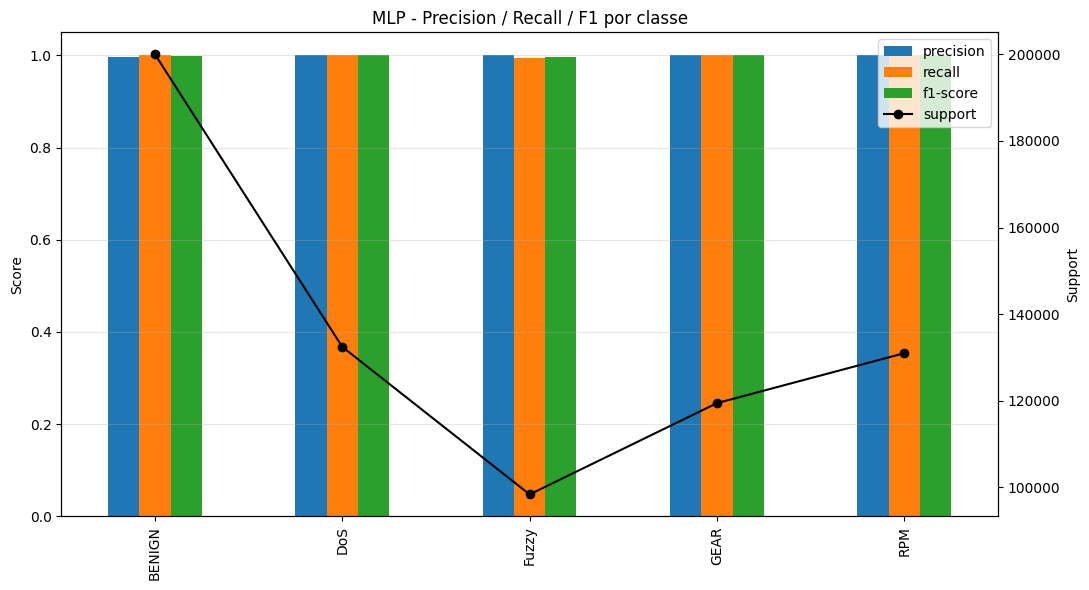

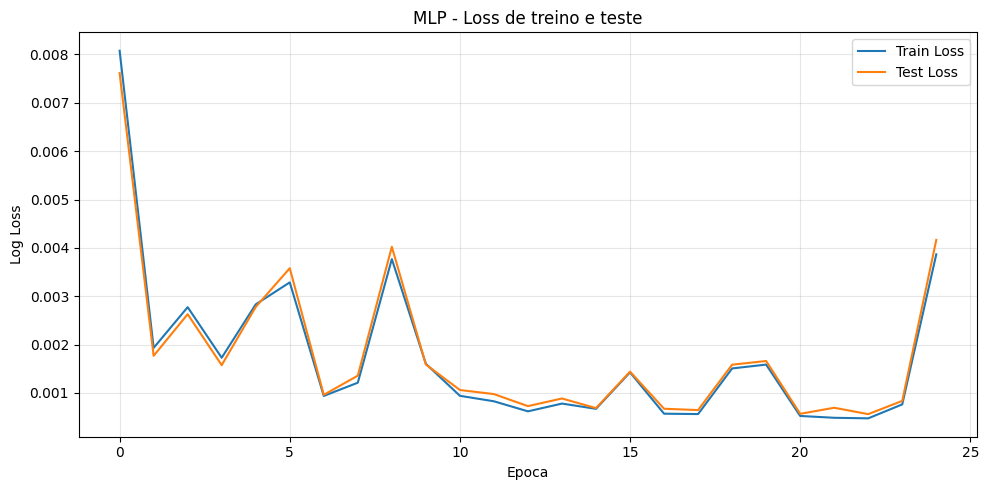

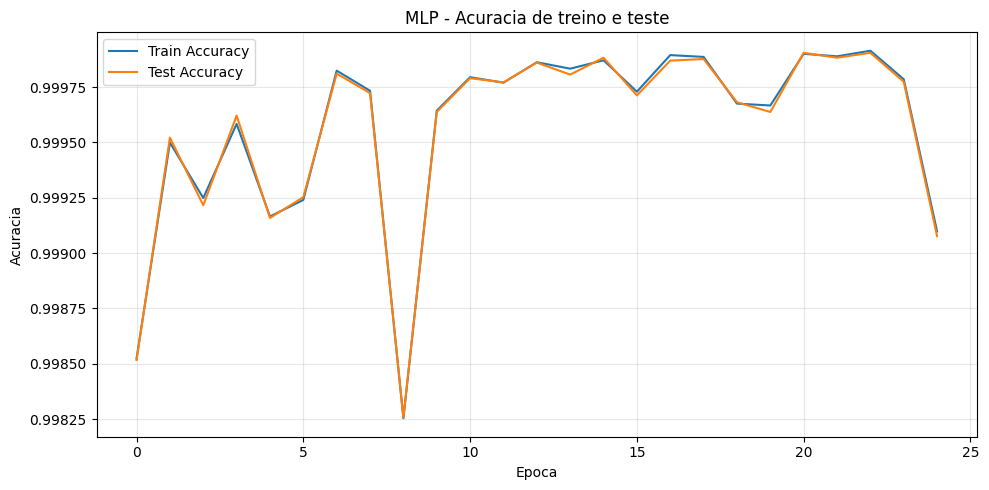

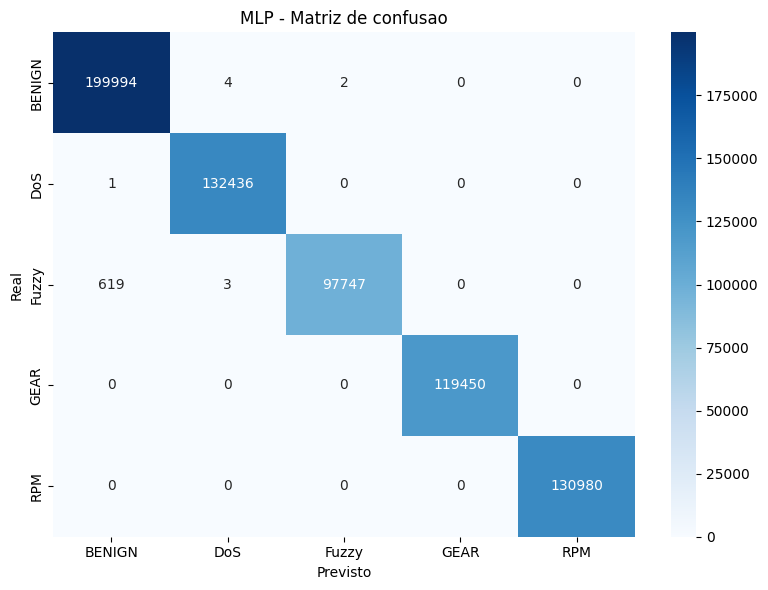

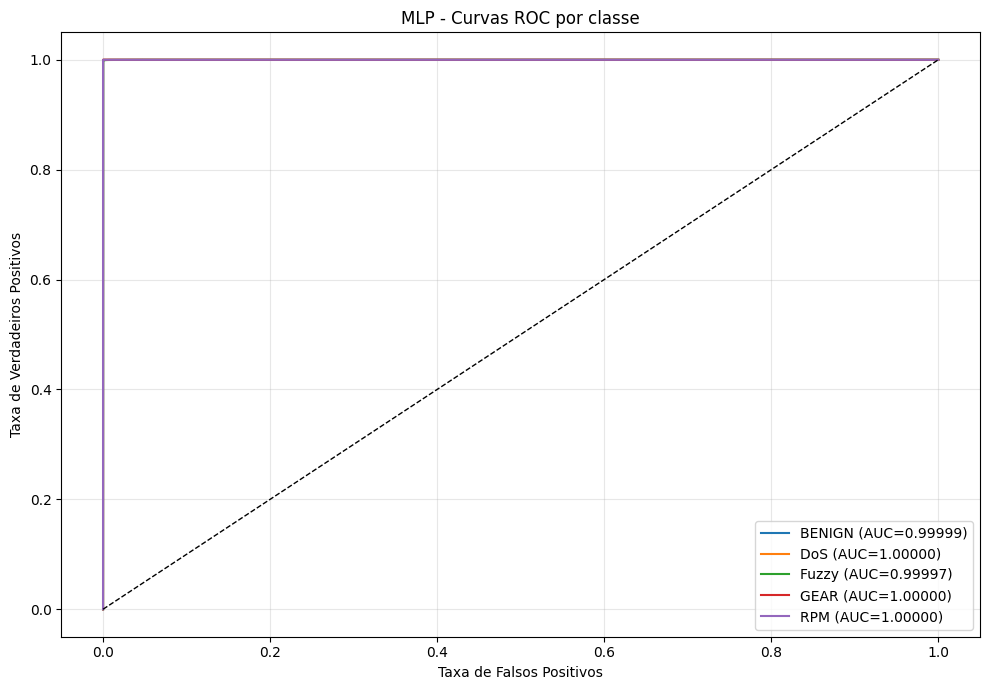

Arquivos salvos em: C:\Users\thelo\Documents\TCC\IOVT-TCC\results\metrics\mlp_final_clean


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    log_loss,
    accuracy_score,
)

RANDOM_STATE = 42
BENIGN_TARGET = 1_000_000
N_EPOCHS = 25
DATA_PATH = Path('../data/processed/carhacking_ciciov_benign_dos_aligned.csv')
OUT_DIR = Path('../results/metrics/mlp_final_clean')
OUT_DIR.mkdir(parents=True, exist_ok=True)

byte_cols = [f'val{i}' for i in range(8)]

# 1) Carregar e limpar conforme melhor experimento do notebook 05
full_df = pd.read_csv(DATA_PATH)
required_cols = ['id', 'dlc'] + byte_cols + ['flag', 'source']
missing = [c for c in required_cols if c not in full_df.columns]
if missing:
    raise ValueError(f'Colunas ausentes no dataset: {missing}')

full_df = full_df[required_cols].dropna().copy()
incomplete_mask = (full_df['source'] == 'CARDT') & (full_df['dlc'] < 8)
print('incomplete CARDT rows removidas:', int(incomplete_mask.sum()))
df_no_incomplete = full_df.loc[~incomplete_mask, ['id'] + byte_cols + ['flag']].copy()

# 2) Balancear BENIGN
benign_df = df_no_incomplete[df_no_incomplete['flag'] == 'BENIGN']
attack_df = df_no_incomplete[df_no_incomplete['flag'] != 'BENIGN']
benign_sampled = benign_df.sample(n=min(BENIGN_TARGET, len(benign_df)), random_state=RANDOM_STATE)
df_balanced = pd.concat([benign_sampled, attack_df], axis=0)
df_balanced = df_balanced.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

le = LabelEncoder()
df_balanced['flag_encoded'] = le.fit_transform(df_balanced['flag'])
X = df_balanced[['id'] + byte_cols].copy()
y = df_balanced['flag_encoded'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=40
)

print('train/test:', X_train.shape, X_test.shape)

# 3) Treinar MLP por epoca para curvas de loss/acuracia
mlp_model = MLPClassifier(
    hidden_layer_sizes=(30, 30, 30),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=1,
    warm_start=True,
    random_state=90,
)

train_loss_list, test_loss_list = [], []
train_acc_list, test_acc_list = [], []

classes = np.unique(y_train)
for epoch in range(N_EPOCHS):
    mlp_model.fit(X_train, y_train)
    train_proba_epoch = mlp_model.predict_proba(X_train)
    test_proba_epoch = mlp_model.predict_proba(X_test)

    train_loss_list.append(log_loss(y_train, train_proba_epoch, labels=classes))
    test_loss_list.append(log_loss(y_test, test_proba_epoch, labels=classes))

    train_acc_list.append(accuracy_score(y_train, mlp_model.predict(X_train)))
    test_acc_list.append(accuracy_score(y_test, mlp_model.predict(X_test)))

# 4) Predicoes finais e metricas
y_pred = mlp_model.predict(X_test)
y_proba = mlp_model.predict_proba(X_test)

report_text = classification_report(y_test, y_pred, target_names=le.classes_.astype(str), digits=5)
print(report_text)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_.astype(str),
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(OUT_DIR / 'classification_report.csv', index=True)
(OUT_DIR / 'classification_report.txt').write_text(report_text, encoding='utf-8')

# 5) Grafico precision/recall/f1/support
class_rows = [c for c in le.classes_.astype(str) if c in report_df.index]
metrics_df = report_df.loc[class_rows, ['precision', 'recall', 'f1-score', 'support']].copy()

fig, ax1 = plt.subplots(figsize=(11, 6))
metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax1)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Score')
ax1.set_title('MLP - Precision / Recall / F1 por classe')
ax1.grid(axis='y', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(np.arange(len(metrics_df)), metrics_df['support'].values, color='black', marker='o', label='support')
ax2.set_ylabel('Support')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'metrics_bar.png', dpi=200)
plt.show()

# 6) Curvas de loss e acuracia
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(test_loss_list, label='Test Loss')
plt.xlabel('Epoca')
plt.ylabel('Log Loss')
plt.title('MLP - Loss de treino e teste')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'loss_curve.png', dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.xlabel('Epoca')
plt.ylabel('Acuracia')
plt.title('MLP - Acuracia de treino e teste')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'accuracy_curve.png', dpi=200)
plt.show()

# 7) Matriz de confusao
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('MLP - Matriz de confusao')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=200)
plt.show()

# 8) Curvas ROC multiclasse
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

plt.figure(figsize=(10, 7))
for i, cls_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls_name} (AUC={roc_auc:.5f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('MLP - Curvas ROC por classe')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curves.png', dpi=200)
plt.show()

# 9) Salvar historico das curvas
history_df = pd.DataFrame({
    'epoch': np.arange(1, N_EPOCHS + 1),
    'train_loss': train_loss_list,
    'test_loss': test_loss_list,
    'train_accuracy': train_acc_list,
    'test_accuracy': test_acc_list,
})
history_df.to_csv(OUT_DIR / 'training_history.csv', index=False)

summary = {
    'model': 'MLPClassifier',
    'data_path': str(DATA_PATH),
    'output_dir': str(OUT_DIR),
    'removed_cardt_dlc_lt_8': int(incomplete_mask.sum()),
    'train_shape': [int(X_train.shape[0]), int(X_train.shape[1])],
    'test_shape': [int(X_test.shape[0]), int(X_test.shape[1])],
    'classes': le.classes_.astype(str).tolist(),
    'final_train_acc': float(train_acc_list[-1]),
    'final_test_acc': float(test_acc_list[-1]),
}
(OUT_DIR / 'run_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print(f'Arquivos salvos em: {OUT_DIR.resolve()}')